Using device: cuda
Epoch 1/5 – test accuracy 91.070%
Epoch 2/5 – test accuracy 93.810%
Epoch 3/5 – test accuracy 95.030%
Epoch 4/5 – test accuracy 95.410%
Epoch 5/5 – test accuracy 95.990%


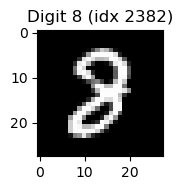

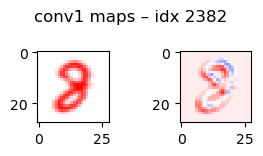

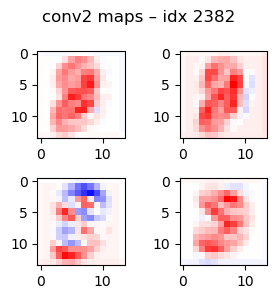

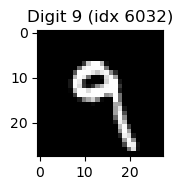

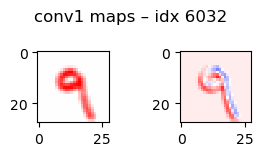

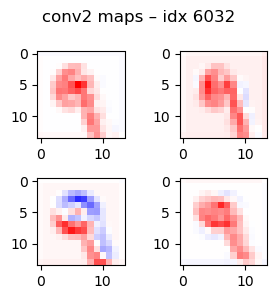

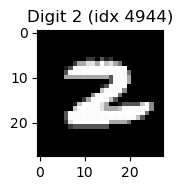

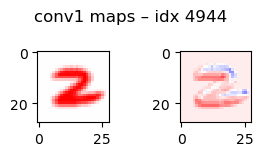

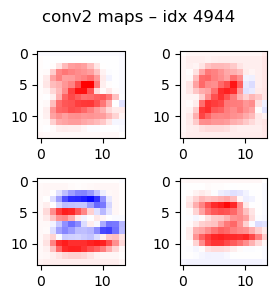

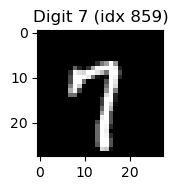

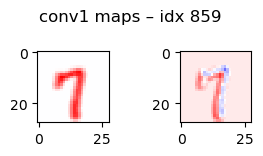

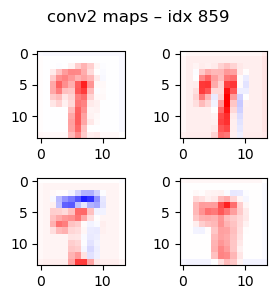

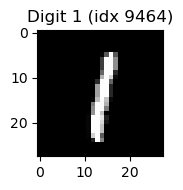

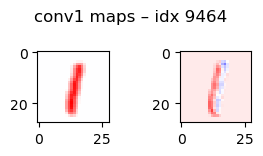

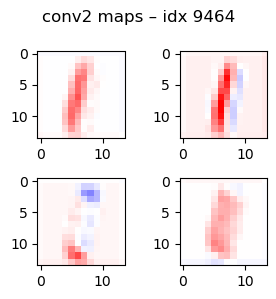

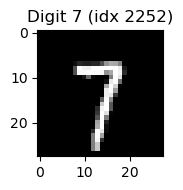

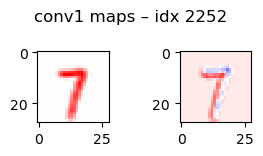

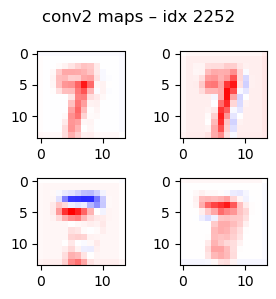

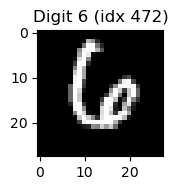

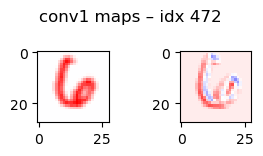

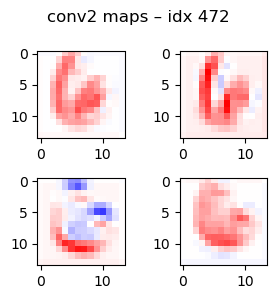

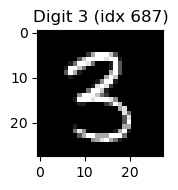

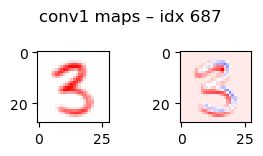

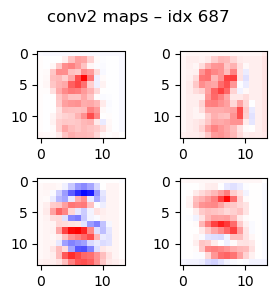

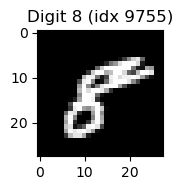

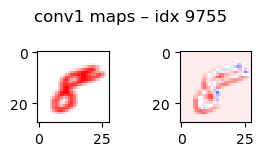

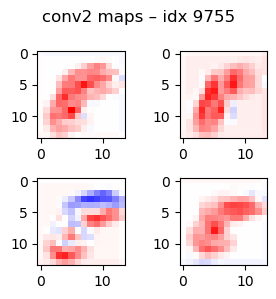

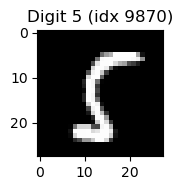

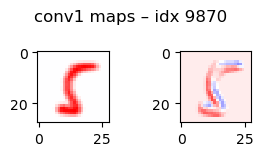

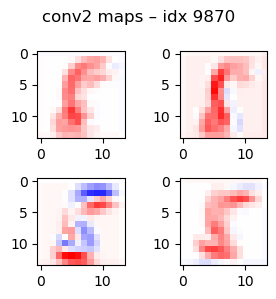


Done. PNGs saved in D:\przemg\PROJECTS\studies\ASQ warszt\activations


In [1]:
#!/usr/bin/env python
# mnist_cnn_vis.py ---------------------------------------------------
"""
Tiny MNIST CNN • blue–white–red activation maps • 10 random digits
No CLI flags – tweak EPOCHS / NUM_VIS below.
"""
# -------------------------------------------------------------------
import numpy as np                          # load NumPy (MKL’s DLL) first
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch                     
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import itertools, math, random
from pathlib import Path
import multiprocessing as mp

# ---------------------- user-tweakable constants -------------------
EPOCHS   = 5          # training epochs
NUM_VIS  = 10         # how many random test digits to visualise
BATCH_TR = 128        # training batch size
SEED     = 123

CLAYER1  = 2 # 8
CLAYER2  = 4 # 16
# -------------------------------------------------------------------

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ----- 1. Dataset ---------------------------------------------------
tfm = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST(root=".", train=True,  download=True, transform=tfm)
test_ds  = datasets.MNIST(root=".", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=BATCH_TR, shuffle=True,
                          num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256,   shuffle=False,
                          num_workers=0)

# ----- 2. Model -----------------------------------------------------
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, CLAYER1, 3, padding=1)   # 28×28 → 28×28
        self.conv2 = nn.Conv2d(CLAYER1, CLAYER2, 3, padding=1)   # 28×28 → 28×28
        self.fc    = nn.Linear(CLAYER2 * 7 * 7, 10)        # after 2×2 pools

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)                        # 28→14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)                        # 14→7
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = TinyCNN().to(DEVICE)

# ----- 3. Training --------------------------------------------------
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(1, EPOCHS + 1):
    model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        F.cross_entropy(model(x), y).backward()
        opt.step()

    # quick test accuracy each epoch
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            correct += (model(x).argmax(1) == y).sum().item()
            total   += y.size(0)
    print(f"Epoch {epoch}/{EPOCHS} – test accuracy {correct/total:.3%}")

# ----- 4. Helper: blue-white-red grid plot -------------------------
def grid_plot(tensor, title):
    """tensor: (C,H,W) on CPU; blue<0, white 0, red>0."""
    n_maps = tensor.size(0)
    cols   = int(math.ceil(math.sqrt(n_maps)))
    rows   = int(math.ceil(n_maps / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))

    vmax = float(torch.abs(tensor).max())
    vmin = -vmax

    for ax, fmap in itertools.zip_longest(axes.flat, tensor):
        if fmap is not None:
            ax.imshow(fmap, cmap="bwr", vmin=vmin, vmax=vmax,
                      interpolation="nearest")
            #ax.axis("off")
        else:
            ax.remove()
    fig.suptitle(title)
    fig.tight_layout()
    return fig

# ----- 5. Visualise NUM_VIS random test digits --------------------
indices = torch.randperm(len(test_ds), generator=torch.Generator().manual_seed(SEED))[:NUM_VIS]
Path("activations").mkdir(exist_ok=True)

def save_hook(layer_name, store):
    def hook(_, __, output):
        store[layer_name] = output.detach().cpu()
        # return None so we DON'T replace the tensor!
    return hook

for idx in indices.tolist():
    img, label = test_ds[idx]
    sample     = img.unsqueeze(0).to(DEVICE)

    activations = {}
    h1 = model.conv1.register_forward_hook(save_hook("conv1", activations))
    h2 = model.conv2.register_forward_hook(save_hook("conv2", activations))

    model.eval(); _ = model(sample)      # forward pass
    h1.remove();  h2.remove()

    # input digit
    plt.figure(figsize=(2,2))
    plt.imshow(sample.squeeze().cpu(), cmap="gray")
    #plt.axis("off")
    plt.title(f"Digit {label} (idx {idx})")
    plt.tight_layout()
    plt.savefig(f"activations/{idx}.png", dpi=150)
    plt.show()

    # activation grids
    for name, act in activations.items():
        fig = grid_plot(act.squeeze(0), f"{name} maps – idx {idx}")
        fig.savefig(f"activations/{idx}_{name}.png", dpi=150)
        plt.show()

print(f"\nDone. PNGs saved in {Path('activations').resolve()}")
# -------------------------------------------------------------------
if __name__ == "__main__":
    mp.freeze_support()          # Windows-exe friendliness
